<a href="https://colab.research.google.com/github/sherjahong1r/Machine-Learning-Lessons/blob/main/02_Data_augmentation_practise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Kerakli kutubxonalar import qilinib olindi

import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd # Bu orqali notebook da audioni eshitish mumkin
import librosa
import librosa.display

In [ ]:
ipd.Audio("/content/audio.mp3")

In [ ]:
data, sr = librosa.load("/content/audio.mp3")
# data - bu fayldagi har bir vaqt nuqtasidagi ovoz balandligi (amplituda) qiymatlari majmuasidir
# sr - U bir sekundda nechta namuna (nuqta) olinganini bildiradi.

In [ ]:
data

array([ 6.8514370e-12,  8.3128670e-13,  5.4599368e-12, ...,
        1.3780183e-05,  7.4437894e-06, -4.4509861e-06], dtype=float32)

In [ ]:
len(data)

166698

In [ ]:
sr

22050

<Figure size 1200x300 with 0 Axes>

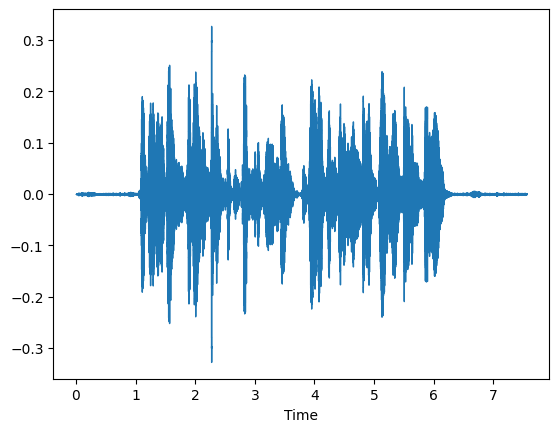

In [ ]:
plt.figure(figsize=(12, 3))
plt.figure()
librosa.display.waveshow(data, sr=sr)
# librosa.display.waveshow(data, sr=sr): Bu librosa kutubxonasining maxsus funksiyasi bo'lib, audio signalining to'lqin shaklini
# (waveform) chizadi. U data (audio ma'lumotlari) va sr (namunalash chastotasi) parametrlari yordamida audio to'lqinni vizualizatsiya qiladi.

## Asl audio ovozga shovqin qo'shildi

In [ ]:
def add_white_noise(signal, noise_percentage_factor):
    noise = np.random.normal(0, data.std(), data.size)
    augmented_signal = signal + noise * noise_percentage_factor
    return augmented_signal

#  add_white_noise funksiyasi audio signaliga 'oq shovqin' (white noise) qo'shish uchun ishlatiladi.
# Qisqacha qilib aytganda:
# Shovqin yaratish: U dastlab audio ma'lumotlarning (bizning holatimizda data o'zgaruvchisidagi) standart
# chetlanishiga (std) mos keladigan tasodifiy 'oq shovqin' hosil qiladi.
# Shovqinni qo'shish: Keyin bu yaratilgan shovqinni asl signal ga qo'shadi.
# Shovqin darajasi: noise_percentage_factor parametri esa qo'shilayotgan shovqinning intensivligini,
# ya'ni qanchalik baland bo'lishini nazorat qiladi.
# Natijada, funksiya asl audio signalining biroz shovqinli, 'kuchaytirilgan' versiyasini qaytaradi.

In [ ]:
augmented_signal = add_white_noise(data, 0.7)

# asl data audio signaliga 0.7 intensivlikdagi oq shovqin qo'shiladi va hosil bo'lgan yangi,
# shovqinli signal augmented_signal o'zgaruvchisiga saqlanadi.

In [ ]:
import soundfile as sf
# soundfile: Bu kutubxona audio fayllar bilan ishlash, masalan, ularni o'qish yoki yozish uchun mo'ljallangan.

In [ ]:
sf.write("augmented_audio_white_noice.wav", augmented_signal, sr)

# sf.write(): Bu soundfile kutubxonasining funksiyasi bo'lib, audio ma'lumotlarini faylga saqlashga imkon beradi.
# "augmented_audio_white_noice.wav": Bu faylning nomi va formati (.wav). Audio shu nom ostida saqlanadi.
# augmented_signal: Bu funksiyaga yoziladigan audio ma'lumotlar, ya'ni add_white_noise funksiyasi yordamida shovqin qo'shilgan signal.
# sr: Bu audio signalining namunalash chastotasi (sampling rate) bo'lib, librosa.load funksiyasi orqali yuklangan asl audio fayldan
# olingan qiymat. Bu qiymat audio faylni to'g'ri tinglash uchun zarur.

In [ ]:
ipd.Audio("augmented_audio_white_noice.wav")
# O'zgartirish kiritilgan va saqlab olingan audioni qaytadan o'qiyabmiz
# yani bunda asl ovozga 0.7 shovqin qo'shilmoqda

<Figure size 1200x300 with 0 Axes>

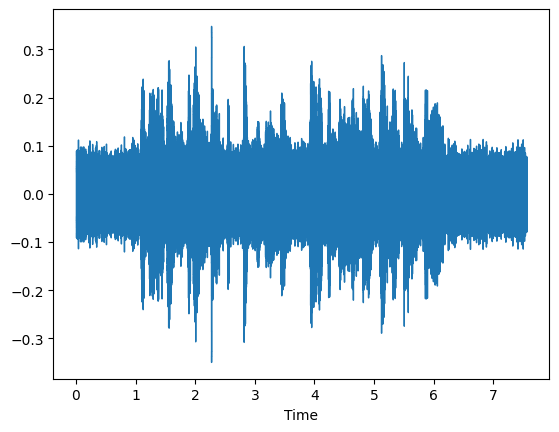

In [ ]:
plt.figure(figsize=(12, 3))
plt.figure()
librosa.display.waveshow(augmented_signal, sr=sr)
# va shovqin qo'shilgan audio ovozi vizualizatsiya qilindi

## Asl audio ovozga maxsus parametrlar orqali tezlashtirish yokida sekinlashtirish va normallashtirish mumkin

https://librosa.org/doc/0.11.0/generated/librosa.effects.harmonic.html

## bu silka orqali audioni yana qanday metodlar bilan o'zgartirish mumkin ekanligini ko'rish mumkin

In [ ]:
def time_stretch(signal, time_stretch_rate):
    return librosa.effects.time_stretch(signal, rate = time_stretch_rate)

# signal: Bu uzaytirilishi yoki qisqartirilishi kerak bo'lgan audio ma'lumotlari.
# time_stretch_rate: Bu signalning qanchalik tez yoki sekin ijro etilishini belgilaydigan koeffitsientdir. Masalan:
# rate = 1.0 asl tezlikni bildiradi.
# rate > 1.0 signalni tezlashtiradi (vaqti qisqaradi).
# rate < 1.0 signalni sekinlashtiradi (vaqti uzayadi).
# Funksiya tezlashtirilgan yoki sekinlashtirilgan audio signalini qaytaradi.

In [ ]:
augmented_signal = time_stretch(data, 1.7)
sf.write("augmented_audio_time_stretch.wav", augmented_signal, sr)

# Audioni tezlashtirib vaqtini qisqartirgan holda saqlab olyabmiz

In [ ]:
ipd.Audio("/content/augmented_audio_time_stretch.wav")

# tezlashtirilgan audioni o'qiyabmiz ipd yordamida

## Audioni yo'g'on yokida ingichka qilib o'zgartirish mumkin

In [4]:
def pitch_scale(signal, sr = 22050, num_semitones = 4):
    return librosa.effects.pitch_shift(y = signal, sr = sr, n_steps = num_semitones)

# pitch_scale funksiyasi audio signalining ohang balandligini (pitch) o'zgartirish uchun ishlatiladi, ya'ni ovozni
# yo'g'onlashtirish yoki ingichkalashtirish imkonini beradi:
# signal: Bu ohangi o'zgartirilishi kerak bo'lgan audio ma'lumotlari.
# sr (sampling rate): Bu audio signalining namunalash chastotasi bo'lib, odatda 22050 qiymati standart hisoblanadi.
#  Bu parametr audio signalini to'g'ri qayta ishlash uchun muhim.
# num_semitones (n_steps): Bu ohangning qancha semiton (yarim ton) ga o'zgarishini belgilaydigan qiymatdir.
# Musbat qiymat ovozni ingichkalashtiradi (ohangni oshiradi).
# Manfiy qiymat ovozni yo'g'onlashtiradi (ohangni pasaytiradi).
# Funksiya o'zgartirilgan ohang balandligiga ega audio signalini qaytaradi.

In [ ]:
augmented_signal = pitch_scale(data, num_semitones = 8)
sf.write("augmented_audio_time_stretch.wav_1", augmented_signal, sr)

# augmented_signal = pitch_scale(data, num_semitones = 8): Bu qator pitch_scale funksiyasini chaqiradi.
# data: Asl audio ma'lumotlari signali.
# num_semitones = 8: Bu audio ohangini 8 semitonga oshirishni bildiradi, ya'ni ovozni ancha ingichkalashtiradi. Natijada,
# ohangi o'zgartirilgan audio augmented_signal o'zgaruvchisiga saqlanadi.
# sf.write("augmented_audio_time_stretch.wav", augmented_signal, sr): Bu qator soundfile kutubxonasi yordamida
# augmented_signalni augmented_audio_time_stretch.wav nomli faylga, asl sr (sampling rate) bilan yozadi.

In [ ]:
ipd.Audio("/content/augmented_audio_time_stretch.wav_1")